In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df_sapxep_DH1 = df.sort_values(by='DH1')
print(df_sapxep_DH1[['T1','DH1']])

      T1   DH1
STT           
54   4.9  1.00
44   6.6  1.25
6    9.3  1.50
73   5.5  1.50
84   5.9  1.75
..   ...   ...
7    2.8  6.50
12   7.9  6.75
24   5.3  6.75
25   2.4  7.00
98   8.8  7.00

[100 rows x 2 columns]


In [13]:
#Phần 1
#câu1
dh1_sorted = df['DH1'].sort_values()
print(dh1_sorted)

STT
54    1.00
44    1.25
6     1.50
73    1.50
84    1.75
      ... 
7     6.50
12    6.75
24    6.75
25    7.00
98    7.00
Name: DH1, Length: 100, dtype: float64


In [14]:
#Câu 2
dh2_sorted_by_gender = df.groupby('GT')['DH2'].apply(lambda x: x.sort_values().reset_index(drop=True))
print(dh2_sorted_by_gender)

GT    
F   0     1.50
    1     2.00
    2     2.25
    3     2.25
    4     2.75
          ... 
M   47    6.00
    48    6.50
    49    6.50
    50    6.75
    51    8.00
Name: DH2, Length: 100, dtype: float64


In [15]:
#Câu 3
def q1(x): return x.quantile(0.25)
def q3(x): return x.quantile(0.75)

pivot1 = df.groupby('KT')['DH1'].agg([
    'count', 'sum', 'mean', 'median', 'min', 'max', 'std', q1, 'median', q3
]).rename(columns={'q1': 'Q1', 'median': 'Q2', 'q3': 'Q3'})
print(pivot1)

    count     sum      mean    Q2   min   max       std      Q1    Q2     Q3
KT                                                                          
A      49  163.50  3.336735  3.25  1.00  6.50  1.274296  2.2500  3.25  4.250
A1      6   17.50  2.916667  3.00  2.00  4.25  0.861201  2.1875  3.00  3.250
B       9   29.50  3.277778  3.50  1.75  4.50  0.823905  3.2500  3.50  3.750
C      14   79.25  5.660714  5.25  4.75  7.00  0.812209  5.0625  5.25  6.375
D1     22   84.25  3.829545  3.75  1.25  6.75  1.370146  3.0000  3.75  4.875


In [16]:
#cau 4
pivot2 = df.groupby(['KT', 'KV'])['DH1'].agg([
    'count', 'sum', 'mean', 'median', 'min', 'max', 'std', q1, 'median', q3
]).rename(columns={'q1': 'Q1', 'median': 'Q2', 'q3': 'Q3'})
print(pivot2)

        count    sum      mean     Q2   min   max       std      Q1     Q2  \
KT KV                                                                        
A  1       29  93.75  3.232759  3.250  1.00  6.50  1.369194  2.0000  3.250   
   2        9  31.75  3.527778  3.500  2.00  6.25  1.427653  2.2500  3.500   
   2NT     11  38.00  3.454545  3.500  2.00  4.75  0.913908  2.8750  3.500   
A1 1        2   4.75  2.375000  2.375  2.00  2.75  0.530330  2.1875  2.375   
   2NT      4  12.75  3.187500  3.250  2.00  4.25  0.921389  2.9375  3.250   
B  1        8  25.75  3.218750  3.375  1.75  4.50  0.860207  3.0000  3.375   
   2NT      1   3.75  3.750000  3.750  3.75  3.75       NaN  3.7500  3.750   
C  1        8  43.50  5.437500  5.250  4.75  7.00  0.728869  5.0000  5.250   
   2        2  11.50  5.750000  5.750  5.00  6.50  1.060660  5.3750  5.750   
   2NT      4  24.25  6.062500  6.000  5.25  7.00  0.943729  5.2500  6.000   
D1 1       13  46.75  3.596154  3.500  1.50  5.75  1.264658  2.7

In [19]:
#cau 5
pivot3 = df.groupby(['KT', 'KV', 'DT'])['DH1'].agg([
    'count', 'sum', 'mean', 'median', 'min', 'max', 'std', q1, 'median', q3
]).rename(columns={'q1': 'Q1', 'median': 'Q2', 'q3': 'Q3'})
print(pivot3)

           count   sum  mean    Q2   min   max  std    Q1    Q2    Q3
KT KV DT                                                             
A  2  6.0      1  4.25  4.25  4.25  4.25  4.25  NaN  4.25  4.25  4.25
D1 1  1.0      1  3.00  3.00  3.00  3.00  3.00  NaN  3.00  3.00  3.00
   2  1.0      1  1.25  1.25  1.25  1.25  1.25  NaN  1.25  1.25  1.25


    Tần số  Tần suất %
GT                    
M       52        52.0
F       48        48.0


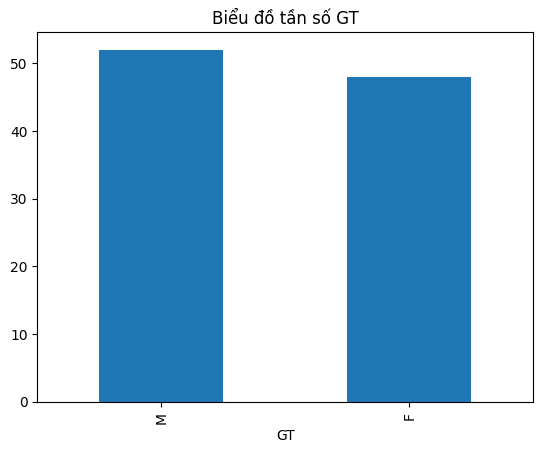

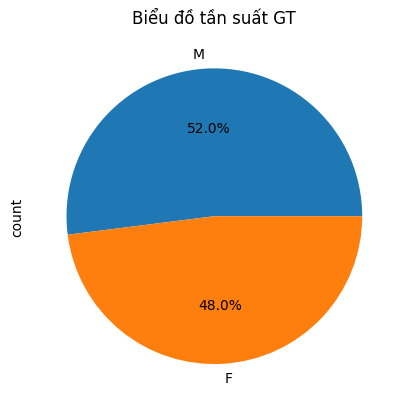

In [20]:
#phan 2
# cau 1
freq = df['GT'].value_counts()
freq_pct = df['GT'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Tần số': freq, 'Tần suất %': freq_pct}))

# Biểu đồ cột
freq.plot(kind='bar', title='Biểu đồ tần số GT')
plt.show()

# Biểu đồ tròn
freq.plot(kind='pie', autopct='%1.1f%%', title='Biểu đồ tần suất GT')
plt.show()


--- DH1 ---
count    100.000000
mean       3.740000
std        1.424408
min        1.000000
25%        2.500000
50%        3.625000
75%        4.750000
max        7.000000
Name: DH1, dtype: float64


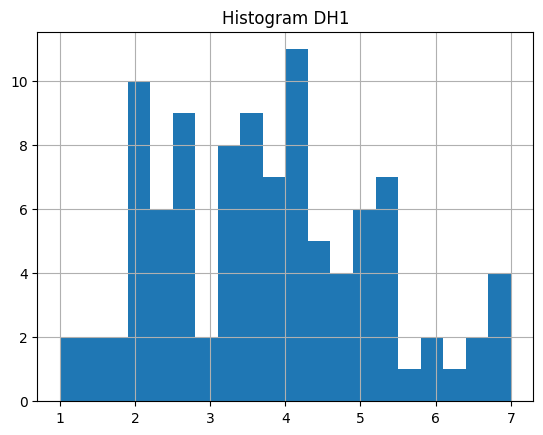


--- DH2 ---
count    100.000000
mean       4.255000
std        1.060053
min        1.500000
25%        3.500000
50%        4.125000
75%        4.750000
max        8.000000
Name: DH2, dtype: float64


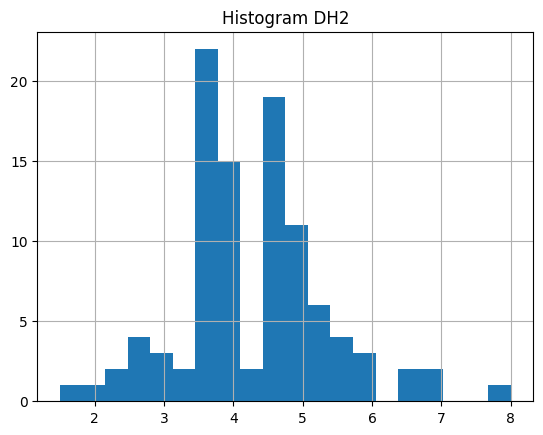


--- DH3 ---
count    100.000000
mean       4.875000
std        1.041136
min        2.750000
25%        4.250000
50%        4.750000
75%        5.500000
max        8.000000
Name: DH3, dtype: float64


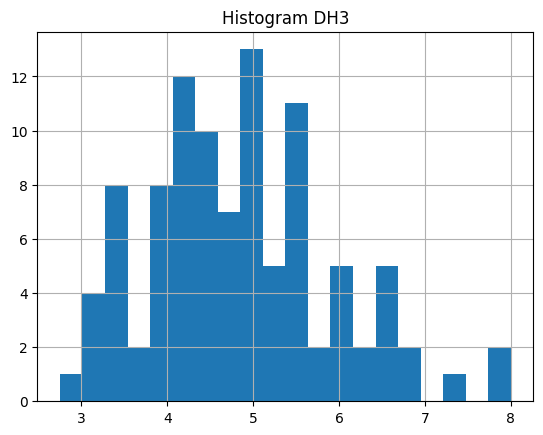

In [26]:
#cau2
for col in ['DH1', 'DH2', 'DH3']:
    print(f"\n--- {col} ---")
    print(df[col].describe())
    df[col].hist(bins=20)
    plt.title(f'Histogram {col}')
    plt.show()

In [28]:
#cau3
nam = df[df['GT'] == 'Nam']
freq_dt_nam = nam['DT'].value_counts()
print(freq_dt_nam)

Series([], Name: count, dtype: int64)


In [29]:
#cau4
dk = df[(df['GT'] == 'Nam') & (df['DT'] == 'Kinh') & (df['DH1'] >= 5) & (df['DH2'] >= 4) & (df['DH3'] >= 4)]
print(dk['KV'].value_counts())

Series([], Name: count, dtype: int64)


In [30]:
#cau5
dk2 = df[(df['DH1'] >= 5) & (df['DH2'] >= 5) & (df['DH3'] >= 5) & (df['KV'] == '2NT')]
for col in ['DH1', 'DH2', 'DH3']:
    print(f"{col}:")
    print(dk2[col].describe())

DH1:
count    1.00
mean     6.75
std       NaN
min      6.75
25%      6.75
50%      6.75
75%      6.75
max      6.75
Name: DH1, dtype: float64
DH2:
count    1.00
mean     5.25
std       NaN
min      5.25
25%      5.25
50%      5.25
75%      5.25
max      5.25
Name: DH2, dtype: float64
DH3:
count    1.0
mean     5.0
std      NaN
min      5.0
25%      5.0
50%      5.0
75%      5.0
max      5.0
Name: DH3, dtype: float64


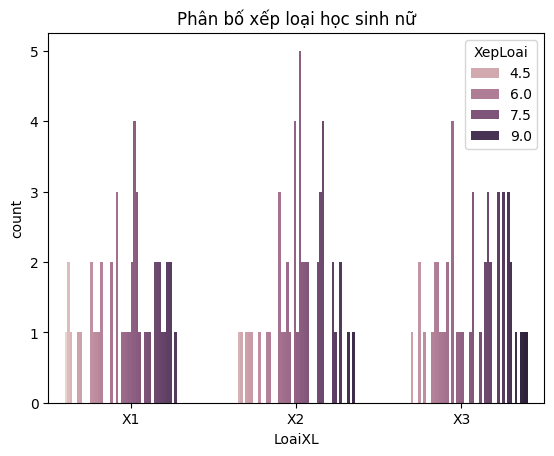

In [35]:
import seaborn as sns
#phan3
#cau1
nu = df[df['GT'] == 'F']
melted = nu.melt(id_vars=['GT'], value_vars=['X1', 'X2', 'X3'], var_name='LoaiXL', value_name='XepLoai')
sns.countplot(data=melted, x='LoaiXL', hue='XepLoai')
plt.title('Phân bố xếp loại học sinh nữ')
plt.show()

In [37]:
#cau 2
dk3 = df[df['KT'].isin(['A', 'A1', 'B']) & df['KV'].isin([1, 2])]
sns.countplot(data=dk3, x='KT', hue='KQXT')
plt.title('KQXT theo khối thi (KV 1,2)')
plt.show()

ValueError: Could not interpret value `KQXT` for `hue`. An entry with this name does not appear in `data`.

In [38]:
#cau3
pd.crosstab(df['KV'], df['KhoiThi']).plot(kind='bar', stacked=True)
plt.title('Số lượng TS từng KV theo khối thi')
plt.show()

KeyError: 'KhoiThi'

In [39]:
#cau4
pd.crosstab(df['KQXT'], df['KhoiThi']).plot(kind='bar', stacked=True)
plt.title('Đậu/rớt theo khối thi')
plt.show()

KeyError: 'KQXT'

In [40]:
#cau5
pd.crosstab(df['KQXT'], df['KV']).plot(kind='bar', stacked=True)
plt.title('Đậu/rớt theo khu vực')
plt.show()

KeyError: 'KQXT'

In [41]:
#cau 6
pd.crosstab(df['KQXT'], df['DT']).plot(kind='bar', stacked=True)
plt.title('Đậu/rớt theo dân tộc')
plt.show()

KeyError: 'KQXT'

In [42]:
#cau 7
pd.crosstab(df['KQXT'], df['GT']).plot(kind='bar', stacked=True)
plt.title('Đậu/rớt theo giới tính')
plt.show()

KeyError: 'KQXT'

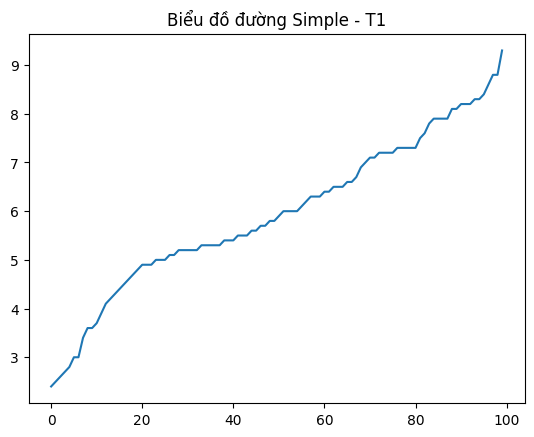

In [43]:
#phan4
# cau1
plt.plot(df['T1'].sort_values().reset_index(drop=True))
plt.title('Biểu đồ đường Simple - T1')
plt.show()

In [48]:
#cau2
def phanloai_t1(x):
    if x < 5: return 'k'
    elif x < 7: return 'tb'
    elif x < 8: return 'kha'
    else: return 'g'

df['phanlopT1'] = df['T1'].apply(phanloai_t1)

In [49]:
#cau3
print(df['phanlopT1'].value_counts())

phanlopT1
tb     46
k      23
kha    19
g      12
Name: count, dtype: int64


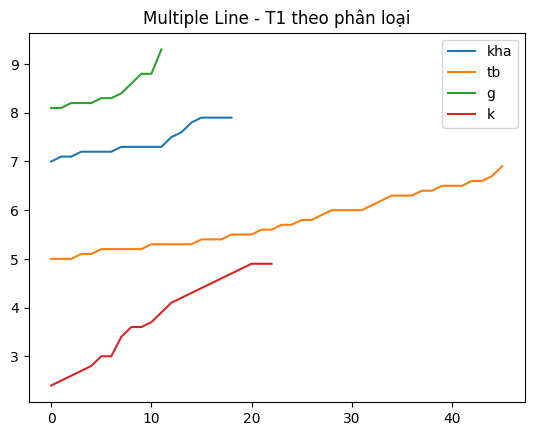

In [50]:
#cau4
for loai in df['phanlopT1'].unique():
    subset = df[df['phanlopT1'] == loai]['T1'].sort_values().reset_index(drop=True)
    plt.plot(subset, label=loai)
plt.legend()
plt.title('Multiple Line - T1 theo phân loại')
plt.show()

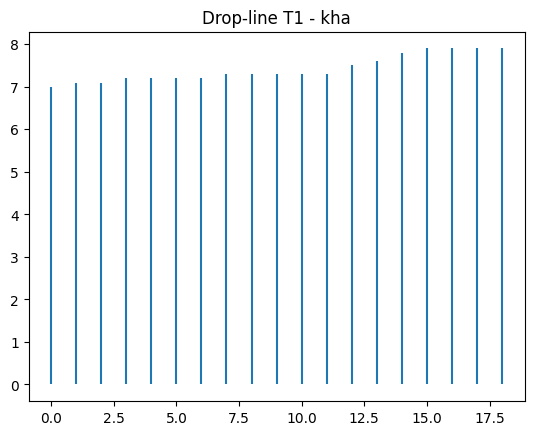

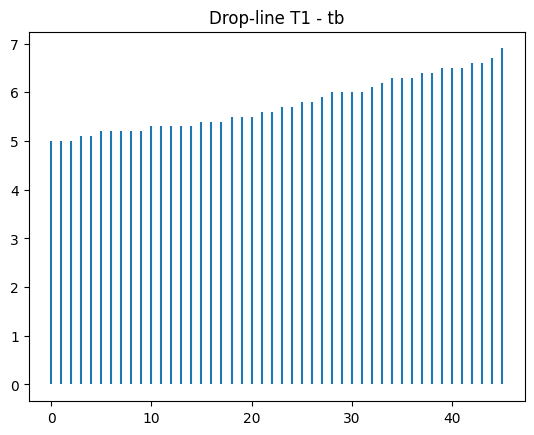

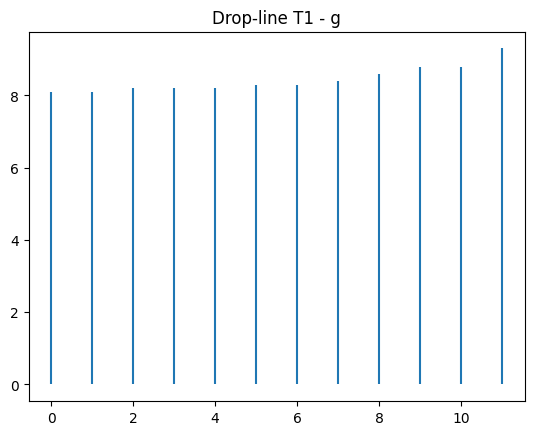

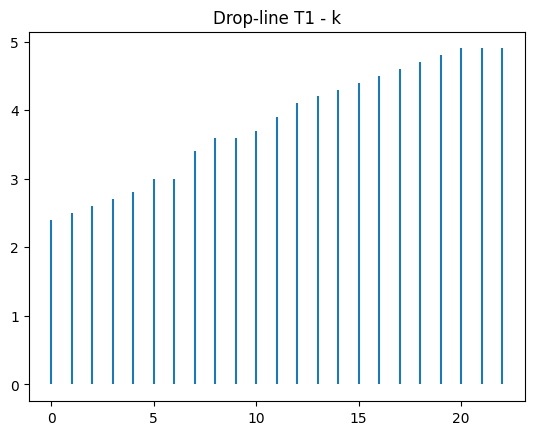

In [51]:
#cau5
for loai in df['phanlopT1'].unique():
    subset = df[df['phanlopT1'] == loai]['T1'].sort_values().reset_index(drop=True)
    plt.stem(subset, linefmt='C0-', markerfmt=' ', basefmt=' ')
    plt.title(f'Drop-line T1 - {loai}')
    plt.show()

count    100.000000
mean       5.946000
std        1.608338
min        2.400000
25%        5.000000
50%        5.850000
75%        7.200000
max        9.300000
Name: T1, dtype: float64


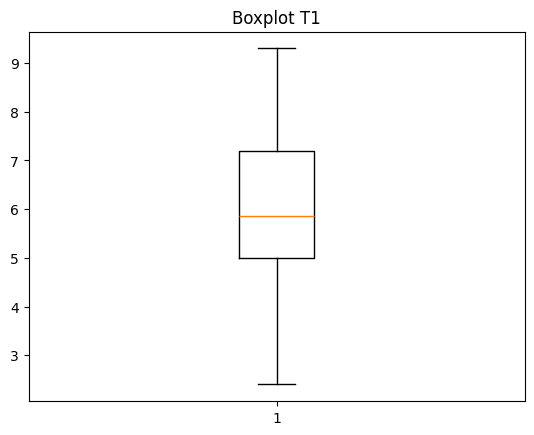

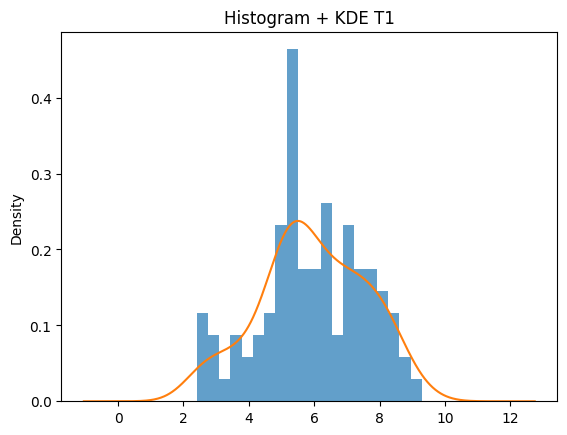

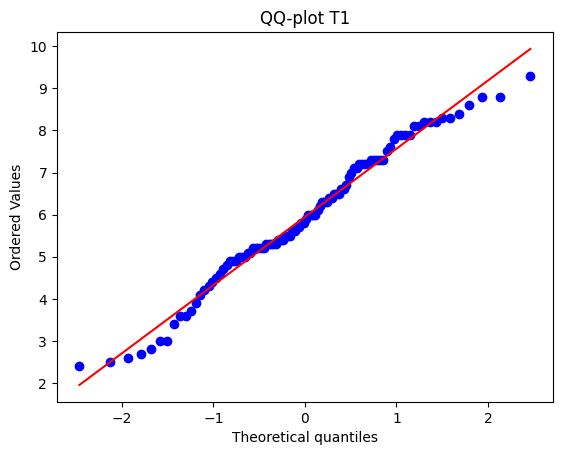

In [53]:
#phan5
#cau1
# Độ tập trung & phân tán
import scipy.stats as stats
print(df['T1'].describe())

# Boxplot
plt.boxplot(df['T1'].dropna())
plt.title('Boxplot T1')
plt.show()

# Histogram
df['T1'].hist(bins=20, density=True, alpha=0.7)
df['T1'].plot.kde()
plt.title('Histogram + KDE T1')
plt.show()

# QQ-plot
stats.probplot(df['T1'].dropna(), dist="norm", plot=plt)
plt.title('QQ-plot T1')
plt.show()


--- kha ---
count    19.000000
mean      7.421053
std       0.311945
min       7.000000
25%       7.200000
50%       7.300000
75%       7.700000
max       7.900000
Name: T1, dtype: float64


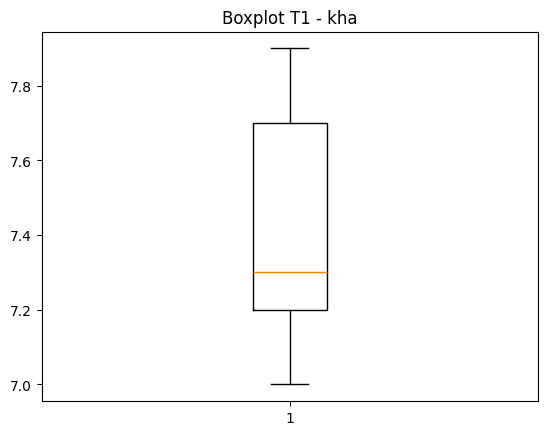

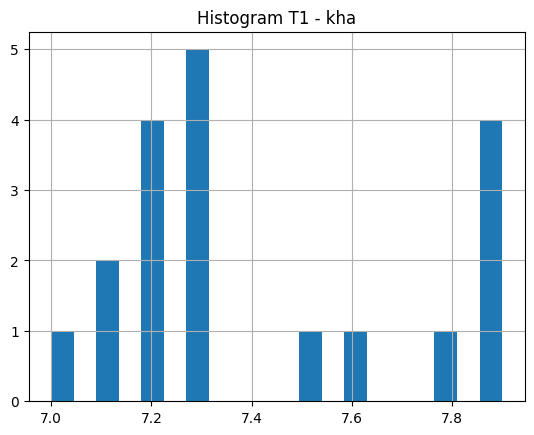

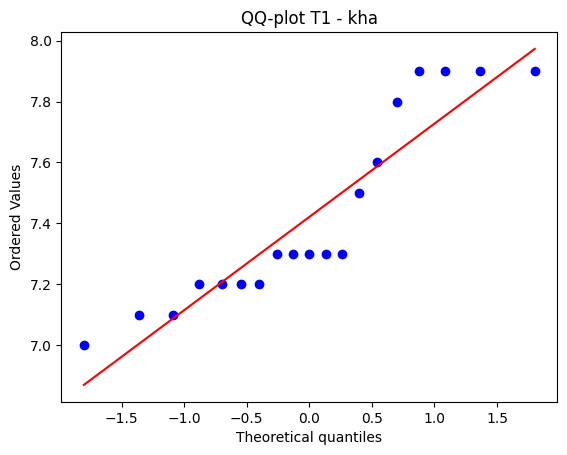


--- tb ---
count    46.000000
mean      5.756522
std       0.545141
min       5.000000
25%       5.300000
50%       5.650000
75%       6.275000
max       6.900000
Name: T1, dtype: float64


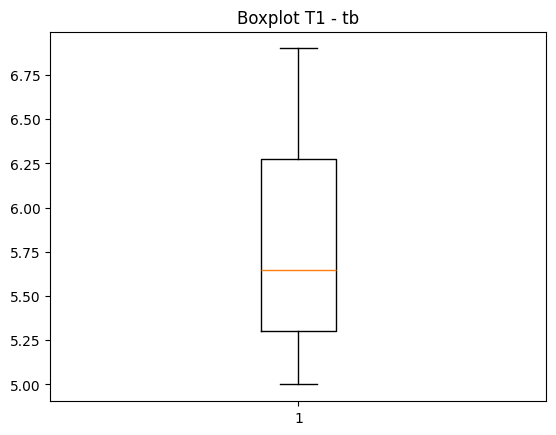

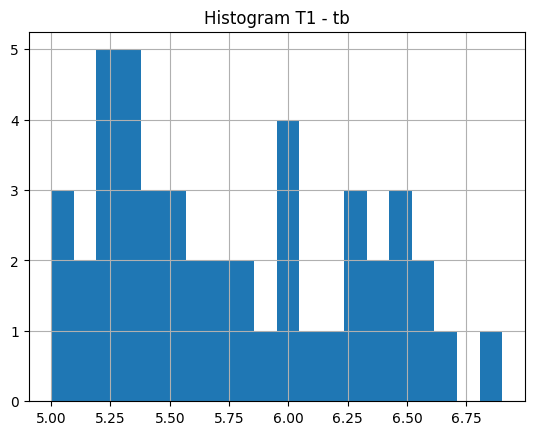

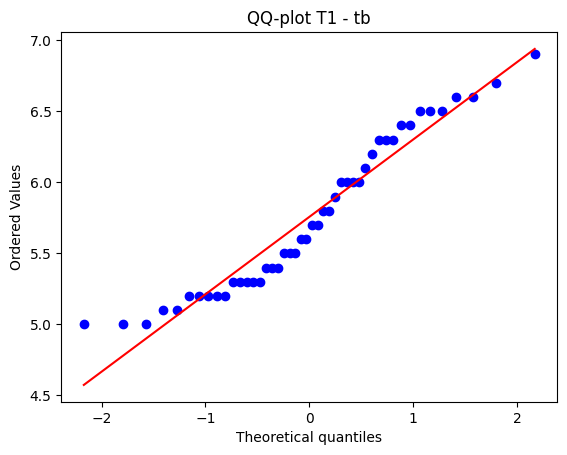


--- g ---
count    12.000000
mean      8.441667
std       0.365459
min       8.100000
25%       8.200000
50%       8.300000
75%       8.650000
max       9.300000
Name: T1, dtype: float64


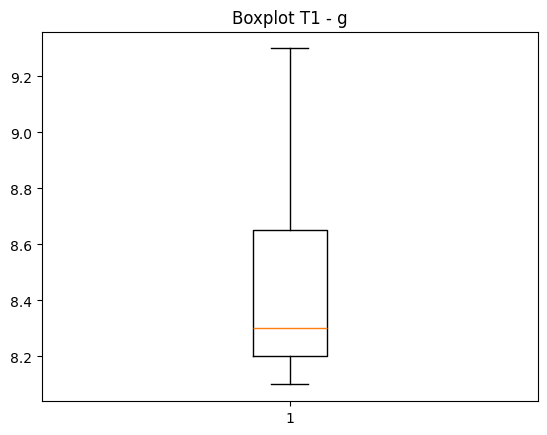

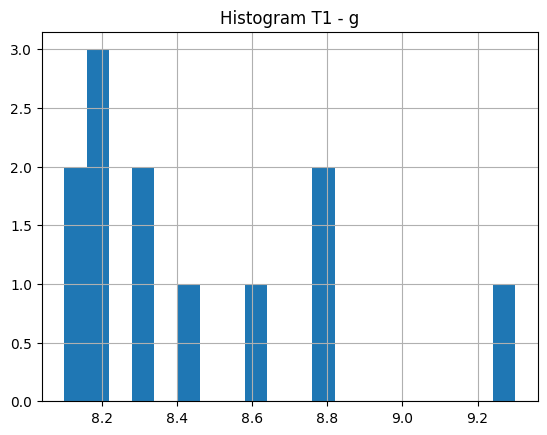

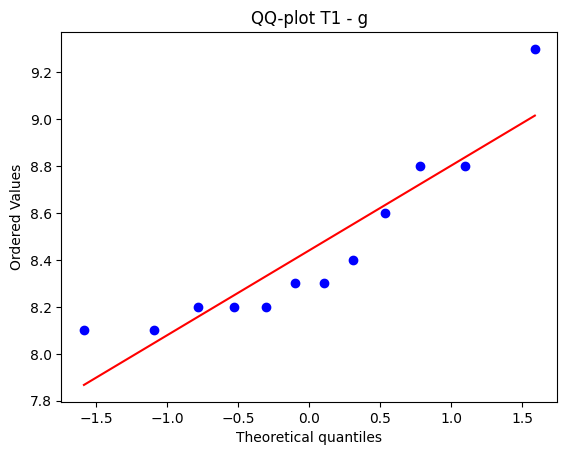


--- k ---
count    23.000000
mean      3.804348
std       0.859957
min       2.400000
25%       3.000000
50%       3.900000
75%       4.550000
max       4.900000
Name: T1, dtype: float64


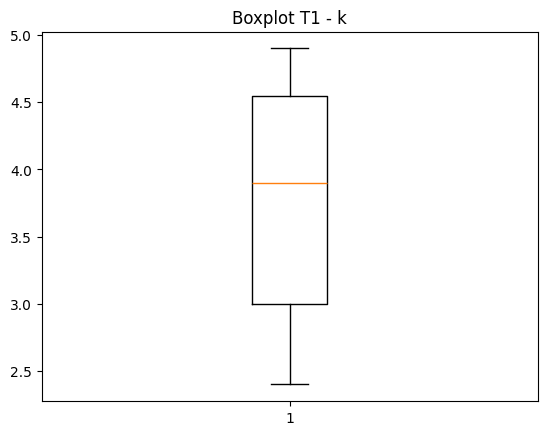

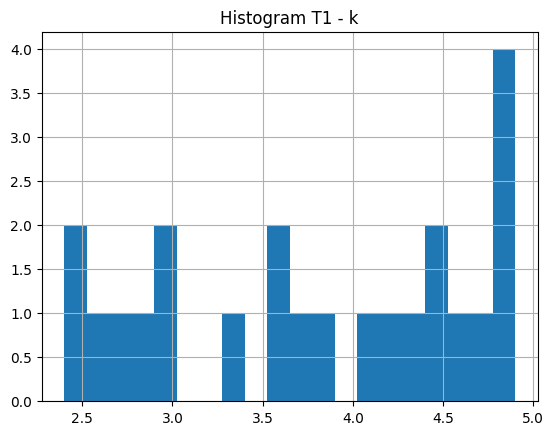

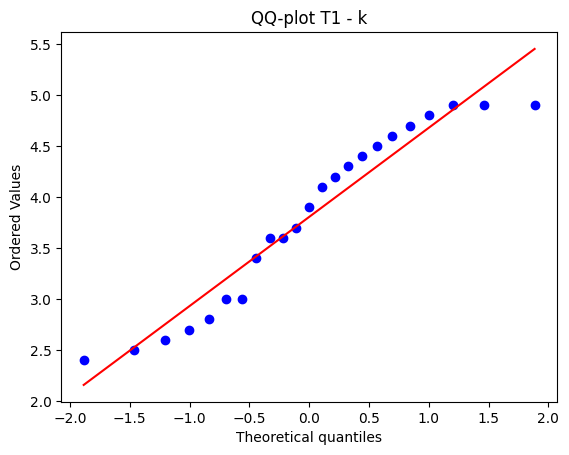

In [54]:
#cau2
for loai in df['phanlopT1'].unique():
    subset = df[df['phanlopT1'] == loai]['T1'].dropna()
    print(f"\n--- {loai} ---")
    print(subset.describe())

    plt.boxplot(subset)
    plt.title(f'Boxplot T1 - {loai}')
    plt.show()

    subset.hist(bins=20)
    plt.title(f'Histogram T1 - {loai}')
    plt.show()

    stats.probplot(subset, dist="norm", plot=plt)
    plt.title(f'QQ-plot T1 - {loai}')
    plt.show()

Covariance: 0.11283838383838381, Correlation: 0.04925439216104145


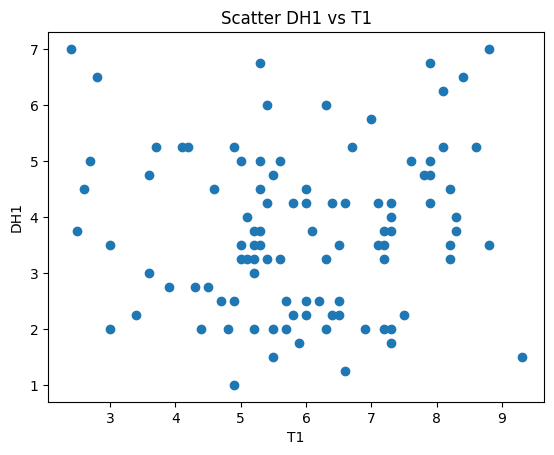

In [55]:
#cau3
cov = np.cov(df['DH1'], df['T1'])[0,1]
corr = df['DH1'].corr(df['T1'])
print(f"Covariance: {cov}, Correlation: {corr}")

plt.scatter(df['T1'], df['DH1'])
plt.xlabel('T1')
plt.ylabel('DH1')
plt.title('Scatter DH1 vs T1')
plt.show()

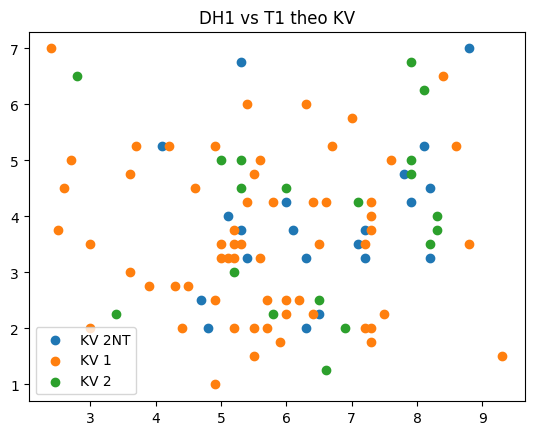

In [56]:
#cau4
for kv in df['KV'].unique():
    subset = df[df['KV'] == kv]
    plt.scatter(subset['T1'], subset['DH1'], label=f'KV {kv}')
plt.legend()
plt.title('DH1 vs T1 theo KV')
plt.show()

          DH1       DH2       DH3
DH1  2.028939  0.053081  0.027778
DH2  0.053081  1.123712 -0.101010
DH3  0.027778 -0.101010  1.083965
          DH1       DH2       DH3
DH1  1.000000  0.035154  0.018731
DH2  0.035154  1.000000 -0.091523
DH3  0.018731 -0.091523  1.000000


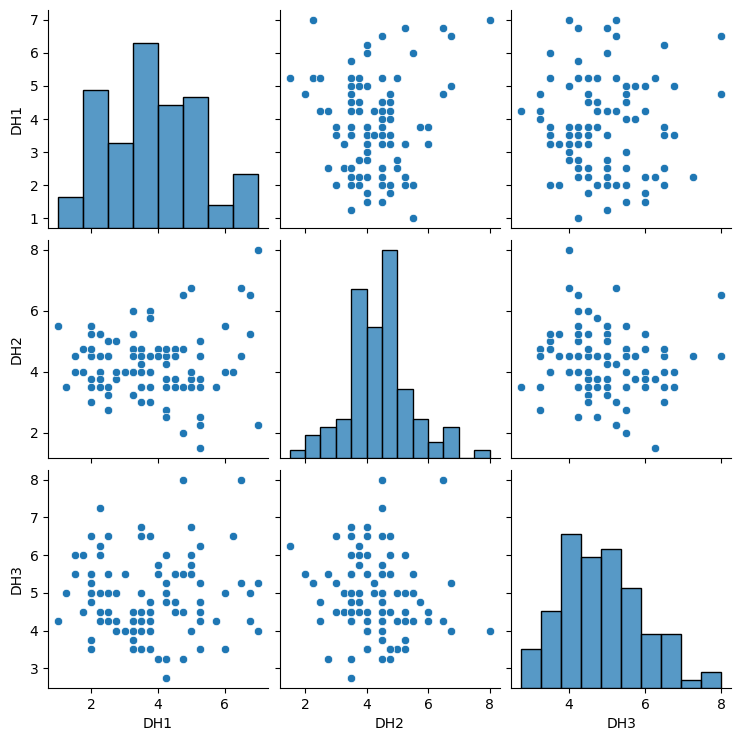

In [57]:
#cau5
print(df[['DH1', 'DH2', 'DH3']].cov())
print(df[['DH1', 'DH2', 'DH3']].corr())

sns.pairplot(df[['DH1', 'DH2', 'DH3']])
plt.show()